<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

<b>ESPECIALIZACIÓN EN CIENCIA DE DATOS E INGELIGENCIA ARTIFICIAL</b>

<strong>Fundamentos de Estadística para Ciencia de Datos</strong>

# Sesión 5 — Análisis multivariado: relaciones y asociación entre variables

## Objetivos de aprendizaje

Al finalizar esta sesión serás capaz de:

- Explicar el concepto de asociación entre variables y por qué asociación no implica causalidad.
- Distinguir tipos de relación: lineal/no lineal, positiva/negativa, fuerte/débil.
- Calcular e interpretar covarianza y correlación de Pearson entre variables numéricas, y reconocer sus limitaciones.
- Aplicar correlaciones de rango (Spearman, Kendall) para relaciones monótonas no lineales.
- Calcular e interpretar Chi-cuadrado, phi y Cramér's V para variables categóricas.
- Medir la asociación entre una variable numérica y una categórica con eta-cuadrado.

---

### Agenda

| # | Tema |
|---|------|
| 1 | El concepto de asociación (y por qué no es causalidad) |
| 2 | Relaciones entre variables numéricas: covarianza y correlación de Pearson |
| 3 | Correlaciones de rango: Spearman y Kendall |
| 4 | Relaciones entre variables categóricas: Chi-cuadrado, phi y Cramér's V |
| 5 | Relación entre variable numérica y categórica: eta-cuadrado |

> **Nota:** las secciones marcadas como **Ejercicio** están pensadas para resolverse en vivo durante la clase; el código queda con `# TODO` a propósito.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

pd.set_option("display.precision", 3)
rng = np.random.default_rng(42)

## 1. El concepto de asociación

Dos variables están **asociadas** cuando conocer el valor de una aporta información sobre el valor probable de la otra: no son independientes. Esto no dice nada sobre la causa: **asociación no implica causalidad**.

El ejemplo clásico: las ventas de helado y las muertes por ahogamiento están fuertemente asociadas mes a mes. Pero una no causa la otra: ambas están impulsadas por una tercera variable, la temperatura (más calor lleva a más gente comprando helado y más gente nadando). Esto se llama una **variable confusora**.

Antes de calcular cualquier número, conviene distinguir tres características de una relación:

- **Forma**: lineal vs. no lineal (¿se ve como una línea recta, o como una curva?).
- **Dirección**: positiva (ambas suben juntas) vs. negativa (una sube, la otra baja).
- **Fuerza**: qué tan cerca están los puntos de seguir el patrón, vs. qué tan dispersos están alrededor de él.

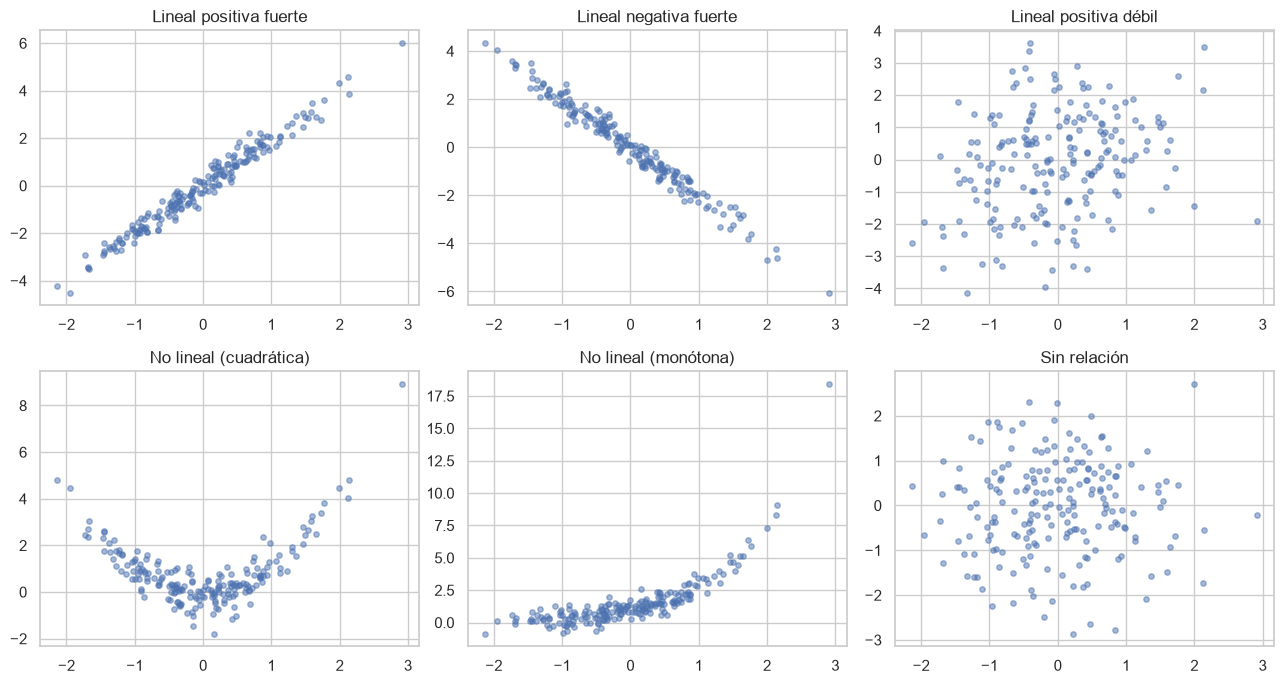

In [2]:
n = 200
x = rng.normal(0, 1, n)

datasets = {
    "Lineal positiva fuerte": (x, 2 * x + rng.normal(0, 0.3, n)),
    "Lineal negativa fuerte": (x, -2 * x + rng.normal(0, 0.3, n)),
    "Lineal positiva débil": (x, 0.5 * x + rng.normal(0, 1.5, n)),
    "No lineal (cuadrática)": (x, x**2 + rng.normal(0, 0.5, n)),
    "No lineal (monótona)": (x, np.exp(x) + rng.normal(0, 0.5, n)),
    "Sin relación": (x, rng.normal(0, 1, n)),
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (title, (xi, yi)) in zip(axes.flat, datasets.items()):
    ax.scatter(xi, yi, alpha=0.5, s=15)
    ax.set_title(title)
plt.tight_layout()
plt.show()

El resto de esta sesión trata de ponerle un número a estas relaciones: primero para dos variables numéricas, luego para dos categóricas, y finalmente para una numérica frente a una categórica.

## 2. Relaciones entre variables numéricas: covarianza y correlación de Pearson

### Covarianza

$$Cov(X,Y) = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})$$

Es un promedio de productos de desviaciones respecto a la media. El signo es interpretable directamente:

- $Cov(X,Y) > 0$: cuando $X$ está por encima de su media, $Y$ tiende a estarlo también (se mueven juntas).
- $Cov(X,Y) < 0$: cuando $X$ está por encima de su media, $Y$ tiende a estar por debajo (se mueven en direcciones opuestas).
- $Cov(X,Y) \approx 0$: no hay un patrón lineal claro entre ambas.

Su **magnitud**, sin embargo, no es directamente interpretable: depende de las unidades y la escala de $X$ y $Y$ (la covarianza entre ingresos en pesos y edad en años no es comparable con la covarianza entre ingresos en dólares y edad en días). Por eso casi nunca se reporta sola: se estandariza como correlación.

### Correlación de Pearson

$$r = \frac{Cov(X,Y)}{s_X \, s_Y}$$

Al dividir por las desviaciones estándar de cada variable, $r$ queda **adimensional** y acotado entre $-1$ y $1$, sin importar las unidades originales, lo que sí permite comparar la fuerza de asociación entre distintos pares de variables.

| Rango de $|r|$ | Interpretación (regla de dedo, no una ley) |
|---|---|
| 0.0 - 0.1 | Prácticamente nula |
| 0.1 - 0.3 | Débil |
| 0.3 - 0.5 | Moderada |
| 0.5 - 0.7 | Fuerte |
| 0.7 - 1.0 | Muy fuerte |

Estos umbrales varían según el campo (en ciencias sociales 0.3 puede considerarse alto; en física, bajo): trátalos como referencia, no como regla fija.

Covarianza(weight, mpg): -5517.44
Correlación de Pearson: -0.832


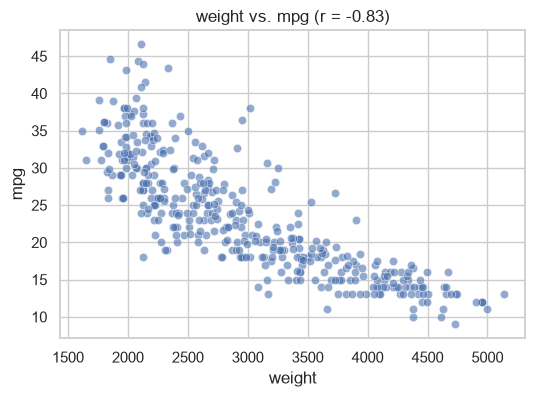

In [3]:
mpg = sns.load_dataset("mpg").dropna()

covarianza = mpg["weight"].cov(mpg["mpg"])
pearson_r = mpg["weight"].corr(mpg["mpg"], method="pearson")

print(f"Covarianza(weight, mpg): {covarianza:.2f}")
print(f"Correlación de Pearson: {pearson_r:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=mpg, x="weight", y="mpg", alpha=0.6, ax=ax)
ax.set_title(f"weight vs. mpg (r = {pearson_r:.2f})")
plt.show()

Cuando hay varias variables numéricas, es común calcular todas las correlaciones de a pares y visualizarlas como un mapa de calor:

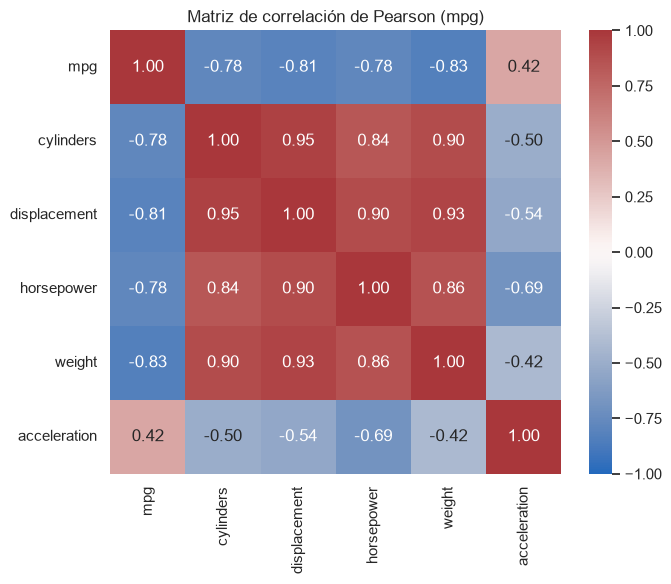

In [4]:
numeric_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration"]
correlation_matrix = mpg[numeric_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación de Pearson (mpg)")
plt.tight_layout()
plt.show()

### La limitación clave de Pearson: solo detecta relaciones lineales

Pearson puede dar un valor cercano a 0 incluso cuando hay una relación clara y fuerte, si esa relación no es lineal:

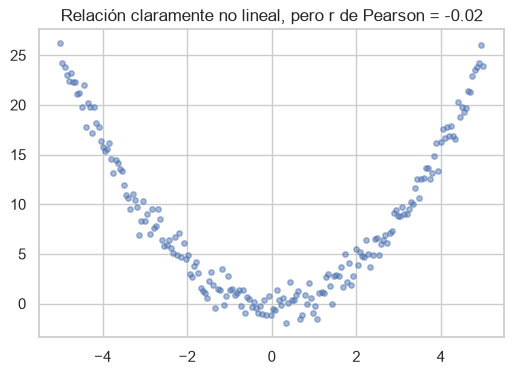

In [5]:
x_quad = np.linspace(-5, 5, 200)
y_quad = x_quad**2 + rng.normal(0, 1, 200)
r_quad = np.corrcoef(x_quad, y_quad)[0, 1]

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x_quad, y_quad, alpha=0.5, s=15)
ax.set_title(f"Relación claramente no lineal, pero r de Pearson = {r_quad:.2f}")
plt.show()

Por eso **siempre conviene graficar antes de confiar en un solo número**: es el mismo espíritu detrás del cuarteto de Anscombe, cuatro conjuntos de datos con la misma correlación de Pearson pero patrones visualmente muy distintos.

**Ejercicio 1:** calcula la covarianza y la correlación de Pearson entre `horsepower` y `acceleration` en `mpg`. ¿El signo tiene sentido físico? ¿Qué tan fuerte es la relación según la tabla de referencia?

In [6]:
# Ejercicio 1: covarianza y correlación de Pearson
# TODO 1: calcula Cov(horsepower, acceleration) y su correlación de Pearson
# TODO 2: interpreta el signo y la fuerza de la relación

## 3. Correlaciones de rango: Spearman y Kendall

Ambas resuelven la limitación de Pearson: no exigen que la relación sea lineal, solo **monótona** (que $Y$ tienda a subir, o a bajar, consistentemente a medida que $X$ sube, sin importar la forma exacta de la curva).

### Correlación de Spearman ($\rho$)

Es la correlación de Pearson calculada sobre los **rangos** de los datos en vez de sus valores originales:

$$\rho = r_{Pearson}\big(\text{rango}(X), \, \text{rango}(Y)\big)$$

Al trabajar con rangos en vez de valores, también es más **robusta a atípicos** que Pearson: un valor extremo mueve su posición en el ranking, pero no puede dominar el cálculo de la forma en que sí puede dominar una covarianza.

### Correlación de Kendall ($\tau$)

Se basa en contar pares. Para cada par de observaciones $(x_i, y_i)$ y $(x_j, y_j)$, el par es **concordante** si ambas variables aumentan juntas (o disminuyen juntas), y **discordante** si una aumenta mientras la otra disminuye:

$$\tau = \frac{(\text{pares concordantes}) - (\text{pares discordantes})}{n(n-1)/2}$$

Suele preferirse sobre Spearman con muestras pequeñas o con muchos valores empatados, y su valor tiene una interpretación más directa (relacionada con la probabilidad de concordancia), a costa de ser más costosa de calcular ($O(n^2)$ pares en vez de $O(n \log n)$).

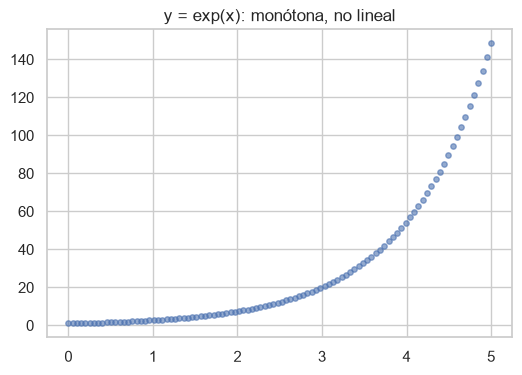

Pearson r:    0.856
Spearman rho: 1.000
Kendall tau:  1.000


In [7]:
x_exp = np.linspace(0, 5, 100)
y_exp = np.exp(x_exp)  # sin ruido: relación monótona perfecta, pero no lineal

r_pearson_exp = np.corrcoef(x_exp, y_exp)[0, 1]
r_spearman_exp, _ = stats.spearmanr(x_exp, y_exp)
r_kendall_exp, _ = stats.kendalltau(x_exp, y_exp)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x_exp, y_exp, alpha=0.6, s=15)
ax.set_title("y = exp(x): monótona, no lineal")
plt.show()

print(f"Pearson r:    {r_pearson_exp:.3f}")
print(f"Spearman rho: {r_spearman_exp:.3f}")
print(f"Kendall tau:  {r_kendall_exp:.3f}")

Spearman y Kendall detectan la relación monótona perfecta (valor máximo posible), mientras que Pearson queda notablemente por debajo de 1 porque la curva no es una línea recta.

Pero ninguna de las tres detecta relaciones **no monótonas** (como la cuadrática de la sección 2):

In [8]:
r_spearman_quad, _ = stats.spearmanr(x_quad, y_quad)

print("Relación cuadrática (no monótona):")
print(f"Pearson r:    {r_quad:.3f}")
print(f"Spearman rho: {r_spearman_quad:.3f}")

Relación cuadrática (no monótona):
Pearson r:    -0.025
Spearman rho: -0.019


Ambas cercanas a 0, aunque claramente existe un patrón: ninguna correlación por sí sola reemplaza mirar el gráfico de dispersión.

**Ejercicio 2:** calcula Spearman y Kendall entre `horsepower` y `mpg` en el dataset `mpg`, y compáralos con la correlación de Pearson entre esas mismas dos variables (ya está en la matriz de correlación de la sección 2). ¿Son muy distintos entre sí? ¿Qué te dice eso sobre la forma de la relación?

In [9]:
# Ejercicio 2: correlaciones de rango
# TODO 1: calcula Spearman y Kendall entre horsepower y mpg
# TODO 2: compáralos con el Pearson de la matriz de correlación (sección 2)

## 4. Relaciones entre variables categóricas: Chi-cuadrado, phi y Cramér's V

En la sesión 4 usamos la tabla de contingencia para describir la relación entre dos variables categóricas. Ahora le ponemos números: ¿esa relación es más fuerte de lo que esperaríamos si las variables fueran independientes?

### Prueba Chi-cuadrado de independencia

Compara las frecuencias **observadas** en la tabla de contingencia contra las frecuencias **esperadas** si las dos variables fueran independientes:

$$E_{ij} = \frac{(\text{total fila } i)(\text{total columna } j)}{n} \qquad \chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

$H_0$: las dos variables son independientes. Un $\chi^2$ grande (y un p-valor bajo) es evidencia en contra de la independencia. Igual que con Shapiro-Wilk en la sesión 3, el p-valor dice si hay evidencia de asociación, **no** qué tan fuerte es — para eso siguen phi y Cramér's V.

(La prueba es poco confiable si alguna frecuencia esperada $E_{ij}$ es menor a 5; con tablas dispersas conviene agrupar categorías antes de aplicarla, como hicimos en la sesión 4.)

### Phi ($\phi$) y Cramér's V

$$\phi = \sqrt{\frac{\chi^2}{n}} \qquad V = \sqrt{\frac{\chi^2}{n \cdot \min(r-1, \, c-1)}}$$

donde $r$ y $c$ son el número de filas y columnas de la tabla. $\phi$ solo queda acotado entre 0 y 1 para tablas $2\times2$; Cramér's V generaliza la idea a tablas de cualquier tamaño, siempre entre 0 (sin asociación) y 1 (asociación perfecta). No son directamente comparables en magnitud con la correlación de Pearson: es una escala distinta, aunque comparten la idea de "0 = nada, 1 = todo".

In [10]:
titanic = sns.load_dataset("titanic")

tabla_contingencia = pd.crosstab(titanic["class"], titanic["survived"])
chi2_stat, p_value, dof, expected = stats.chi2_contingency(tabla_contingencia)

print(f"Chi-cuadrado: {chi2_stat:.2f}")
print(f"p-valor: {p_value:.2e}")
print(f"Grados de libertad: {dof}")

Chi-cuadrado: 102.89
p-valor: 4.55e-23
Grados de libertad: 2


In [11]:
n_obs = tabla_contingencia.to_numpy().sum()
r_dim, c_dim = tabla_contingencia.shape
cramers_v = np.sqrt(chi2_stat / (n_obs * min(r_dim - 1, c_dim - 1)))

print(f"Cramér's V (class vs. survived): {cramers_v:.3f}")

Cramér's V (class vs. survived): 0.340


**Ejercicio 3:** calcula Cramér's V para `sex` vs. `survived` en `titanic`. Compáralo con el que acabamos de calcular para `class` vs. `survived`. ¿Cuál asociación es más fuerte?

In [12]:
# Ejercicio 3: Chi-cuadrado y Cramér's V
# TODO 1: construye la tabla de contingencia sex x survived
# TODO 2: calcula chi2_contingency y luego Cramér's V (aquí sí aplica también phi, por ser tabla 2x2)

## 5. Relación entre variable numérica y categórica: eta-cuadrado

Para ver si una variable categórica se asocia con una numérica, el punto de partida visual ya lo vimos en la sesión 2: comparar la distribución de la variable numérica **por grupo** con un boxplot o violin plot.

Para ponerle un número, **eta-cuadrado** ($\eta^2$) mide qué proporción de la varianza total de la variable numérica se explica por la pertenencia a los grupos:

$$\eta^2 = \frac{SS_{entre}}{SS_{total}} = \frac{\sum_j n_j (\bar{x}_j - \bar{x})^2}{\sum_i (x_i - \bar{x})^2}$$

donde $\bar{x}_j$ es la media del grupo $j$, $n_j$ su tamaño, y $\bar{x}$ la media global. Va de 0 (todos los grupos tienen la misma media: la categoría no explica nada de la variable numérica) a 1 (toda la variabilidad se explica por el grupo). Es, en esencia, la misma idea que $R^2$ en una regresión lineal, aplicada a un predictor categórico en vez de uno numérico.

(Es el mismo cálculo que hace por dentro un ANOVA de un factor, que veremos formalmente cuando cubramos pruebas de hipótesis a fondo — aquí nos quedamos en su versión descriptiva: el tamaño del efecto, sin la prueba de hipótesis asociada.)

Cuando la variable categórica es **binaria** (2 categorías), existe una alternativa equivalente: la **correlación biserial puntual**, que no es más que la correlación de Pearson calculada codificando el grupo como 0/1. Con más de dos categorías esa codificación deja de tener sentido (no hay un orden numérico natural entre "usa", "japan" y "europe"), por eso eta-cuadrado es la opción general.

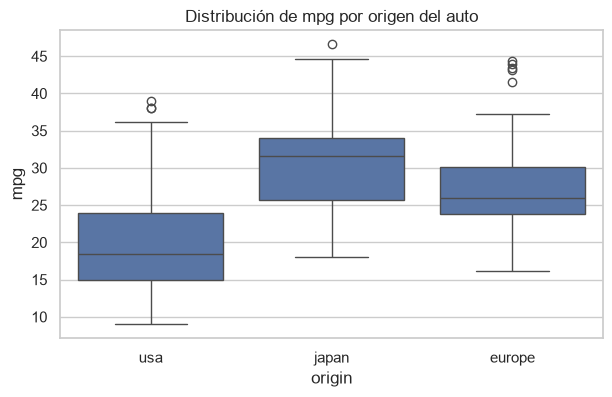

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=mpg, x="origin", y="mpg", ax=ax)
ax.set_title("Distribución de mpg por origen del auto")
plt.show()

In [14]:
media_global = mpg["mpg"].mean()
ss_total = ((mpg["mpg"] - media_global) ** 2).sum()

medias_por_grupo = mpg.groupby("origin")["mpg"].mean()
tamanos_grupo = mpg.groupby("origin")["mpg"].size()
ss_entre = (tamanos_grupo * (medias_por_grupo - media_global) ** 2).sum()

eta_cuadrado = ss_entre / ss_total
print(f"Eta-cuadrado (mpg ~ origin): {eta_cuadrado:.3f}")
print(f"Es decir, el origen explica el {eta_cuadrado:.1%} de la varianza de mpg")

Eta-cuadrado (mpg ~ origin): 0.332
Es decir, el origen explica el 33.2% de la varianza de mpg


**Ejercicio 4:** calcula eta-cuadrado para `horsepower` explicada por `origin`. ¿Es una asociación más fuerte o más débil que la de `mpg` con `origin`?

In [15]:
# Ejercicio 4: eta-cuadrado
# TODO: calcula eta-cuadrado de horsepower ~ origin y compáralo con el de mpg ~ origin

## Cierre

**Ideas clave de hoy:**

- Asociación significa que dos variables no son independientes; **nunca implica causalidad por sí sola** — siempre conviene considerar posibles variables confusoras.
- La covarianza da el signo de una relación lineal, pero su magnitud no es interpretable sin estandarizar; la correlación de Pearson resuelve eso, acotándola entre -1 y 1.
- Pearson solo detecta relaciones **lineales**; Spearman y Kendall detectan relaciones **monótonas** (no necesariamente lineales) usando rangos en vez de valores. Ninguna de las tres detecta relaciones no monótonas, por eso siempre conviene graficar.
- Para variables categóricas, Chi-cuadrado prueba si hay asociación (vía p-valor); phi y Cramér's V miden qué tan fuerte es, de forma análoga a como Pearson mide la fuerza de una relación numérica.
- Eta-cuadrado extiende la misma idea a una variable numérica frente a una categórica: qué proporción de la varianza explica el grupo.

**Preguntas de reflexión:**

1. Piensa en dos variables de tu propio trabajo/tesis que esperarías asociadas. ¿La relación sería lineal o no lineal? ¿Qué variable confusora podría explicar la asociación sin que haya causalidad directa?
2. Si tuvieras una variable categórica ordinal (como nivel educativo) y una numérica, ¿usarías Pearson, Spearman, o eta-cuadrado? ¿Por qué?

**Próxima sesión:** a definir — buen candidato: pruebas de hipótesis e intervalos de confianza con más profundidad (retomando Chi-cuadrado y ANOVA formalmente).